In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Reproducible results
np.random.seed(42)

# Project location
PROJECT_PATH = Path(r"R:\Manufacturing_Production_Analysis")
DATA_PATH = PROJECT_PATH / "Data"

# Create Data folder if it doesn't exist
DATA_PATH.mkdir(parents=True, exist_ok=True)

# Dataset size
n = 720

# Master data
machines = ["WD-01", "WD-02", "STR-01", "STR-02", "GAL-01", "GAL-02"]
shifts = ["A", "B", "C"]
products = [
    "Wire 2.0mm",
    "Wire 3.0mm",
    "Wire Rope 6x19",
    "Wire Rope 6x37"
]

# Production capacity for each machine
capacity = {
    "WD-01": 520,
    "WD-02": 500,
    "STR-01": 430,
    "STR-02": 410,
    "GAL-01": 470,
    "GAL-02": 450
}

# Some machines intentionally have higher downtime
base_downtime = {
    "WD-01": 1.2,
    "WD-02": 1.7,
    "STR-01": 2.0,
    "STR-02": 2.8,
    "GAL-01": 1.5,
    "GAL-02": 3.2
}

base_breakdowns = {
    "WD-01": 1.0,
    "WD-02": 1.3,
    "STR-01": 1.5,
    "STR-02": 2.0,
    "GAL-01": 1.2,
    "GAL-02": 2.2
}

# Generate random machine/shift/product/date data
machine = np.random.choice(machines, n)
shift = np.random.choice(shifts, n)
product = np.random.choice(products, n)
date = np.random.choice(
    pd.date_range("2026-01-01", periods=90, freq="D"),
    n
)

# Machine capacity
production_capacity = np.array([capacity[m] for m in machine])

# Downtime
downtime = np.array([
    max(0, np.random.normal(base_downtime[m], 0.45))
    for m in machine
])
downtime = np.round(downtime, 2)

# Breakdown count
breakdown_count = np.array([
    np.random.poisson(base_breakdowns[m])
    for m in machine
])

# Maintenance / repair hours
maintenance_hours = np.array([
    max(0.2, d * np.random.uniform(0.65, 1.15))
    for d in downtime
])
maintenance_hours = np.round(maintenance_hours, 2)

# Production utilization
utilization = np.clip(
    np.random.normal(0.88, 0.06, n) - downtime * 0.012,
    0.45,
    0.98
)

actual_production = (
    production_capacity * utilization
).astype(int)

# Raw material quality
raw_material_quality = np.random.choice(
    ["Good", "Average", "Poor"],
    n,
    p=[0.72, 0.23, 0.05]
)

# Defect rate depends partly on raw material quality and downtime
defect_rate = []

for quality, d in zip(raw_material_quality, downtime):
    if quality == "Good":
        rate = 0.012
    elif quality == "Average":
        rate = 0.025
    else:
        rate = 0.055

    rate += d * 0.002
    defect_rate.append(min(rate, 0.20))

defect_rate = np.array(defect_rate)

defect_quantity = np.array([
    np.random.binomial(prod, rate)
    for prod, rate in zip(actual_production, defect_rate)
])

# Operators
operators = np.random.choice(
    [2, 3, 4],
    n,
    p=[0.25, 0.55, 0.20]
)

# Create DataFrame
df = pd.DataFrame({
    "Date": date,
    "Shift": shift,
    "Machine": machine,
    "Product": product,
    "Production_Capacity": production_capacity,
    "Actual_Production": actual_production,
    "Downtime_Hours": downtime,
    "Breakdown_Count": breakdown_count,
    "Maintenance_Hours": maintenance_hours,
    "Defect_Quantity": defect_quantity,
    "Operators": operators,
    "Raw_Material_Quality": raw_material_quality
})

# Add a few missing values for cleaning practice
df.loc[10, "Raw_Material_Quality"] = np.nan
df.loc[45, "Raw_Material_Quality"] = np.nan
df.loc[120, "Operators"] = np.nan
df.loc[250, "Operators"] = np.nan

# Add a few inconsistent machine names for cleaning practice
df.loc[30, "Machine"] = "wd-01"
df.loc[75, "Machine"] = "GAL 02"
df.loc[180, "Machine"] = "str-01"
df.loc[310, "Machine"] = "WD 02"

# Add one duplicate row intentionally
df = pd.concat([df, df.iloc[[100]]], ignore_index=True)

# Sort by date
df = df.sort_values("Date").reset_index(drop=True)

# Save CSV
csv_file = DATA_PATH / "manufacturing_production_data.csv"
df.to_csv(csv_file, index=False)

# Save Excel
excel_file = DATA_PATH / "manufacturing_production_data.xlsx"
df.to_excel(excel_file, index=False)

print("Dataset created successfully!")
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print(f"CSV saved at: {csv_file}")
print(f"Excel saved at: {excel_file}")

Dataset created successfully!
Rows: 721
Columns: 12
CSV saved at: R:\Manufacturing_Production_Analysis\Data\manufacturing_production_data.csv
Excel saved at: R:\Manufacturing_Production_Analysis\Data\manufacturing_production_data.xlsx


In [2]:
# 1. Load the dataset
df = pd.read_csv(
    r"R:\Manufacturing_Production_Analysis\Data\manufacturing_production_data.csv"
)
df.head()

,Date,Shift,Machine,Product,Production_Capacity,Actual_Production,Downtime_Hours,Breakdown_Count,Maintenance_Hours,Defect_Quantity,Operators,Raw_Material_Quality
0,2026-01-01,A,WD-01,Wire 2.0mm,520,461,1.23,2,1.02,6,4.0,Good
1,2026-01-01,A,GAL-02,Wire Rope 6x19,450,394,3.36,2,3.59,5,4.0,Good
2,2026-01-01,C,STR-01,Wire 2.0mm,430,381,1.52,0,1.67,10,3.0,Average
3,2026-01-01,B,GAL-02,Wire Rope 6x37,450,384,1.93,0,1.91,6,4.0,Good
4,2026-01-01,B,STR-02,Wire Rope 6x19,410,363,3.15,5,3.53,9,3.0,Good


In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(
    r"R:\Manufacturing_Production_Analysis\Data\manufacturing_production_data.csv"
)

In [5]:
df.head()

,Date,Shift,Machine,Product,Production_Capacity,Actual_Production,Downtime_Hours,Breakdown_Count,Maintenance_Hours,Defect_Quantity,Operators,Raw_Material_Quality
0,2026-01-01,A,WD-01,Wire 2.0mm,520,461,1.23,2,1.02,6,4.0,Good
1,2026-01-01,A,GAL-02,Wire Rope 6x19,450,394,3.36,2,3.59,5,4.0,Good
2,2026-01-01,C,STR-01,Wire 2.0mm,430,381,1.52,0,1.67,10,3.0,Average
3,2026-01-01,B,GAL-02,Wire Rope 6x37,450,384,1.93,0,1.91,6,4.0,Good
4,2026-01-01,B,STR-02,Wire Rope 6x19,410,363,3.15,5,3.53,9,3.0,Good


In [6]:
# . Check dataset size
df.shape

(721, 12)

In [7]:
df.columns

Index(['Date', 'Shift', 'Machine', 'Product', 'Production_Capacity',
       'Actual_Production', 'Downtime_Hours', 'Breakdown_Count',
       'Maintenance_Hours', 'Defect_Quantity', 'Operators',
       'Raw_Material_Quality'],
      dtype='str')

In [8]:
import pandas as pd

In [9]:
df = pd.read_csv(
    r"R:\Manufacturing_Production_Analysis\Data\manufacturing_production_data.csv"
)

In [10]:
df.info

<bound method DataFrame.info of            Date Shift Machine         Product  Production_Capacity  \
0    2026-01-01     A   WD-01      Wire 2.0mm                  520   
1    2026-01-01     A  GAL-02  Wire Rope 6x19                  450   
2    2026-01-01     C  STR-01      Wire 2.0mm                  430   
3    2026-01-01     B  GAL-02  Wire Rope 6x37                  450   
4    2026-01-01     B  STR-02  Wire Rope 6x19                  410   
..          ...   ...     ...             ...                  ...   
716  2026-03-31     C  GAL-02  Wire Rope 6x37                  450   
717  2026-03-31     B  STR-01      Wire 2.0mm                  430   
718  2026-03-31     C   WD-02  Wire Rope 6x19                  500   
719  2026-03-31     B  GAL-02      Wire 2.0mm                  450   
720  2026-03-31     C  GAL-01  Wire Rope 6x37                  470   

     Actual_Production  Downtime_Hours  Breakdown_Count  Maintenance_Hours  \
0                  461            1.23           

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 721 entries, 0 to 720
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  721 non-null    str    
 1   Shift                 721 non-null    str    
 2   Machine               721 non-null    str    
 3   Product               721 non-null    str    
 4   Production_Capacity   721 non-null    int64  
 5   Actual_Production     721 non-null    int64  
 6   Downtime_Hours        721 non-null    float64
 7   Breakdown_Count       721 non-null    int64  
 8   Maintenance_Hours     721 non-null    float64
 9   Defect_Quantity       721 non-null    int64  
 10  Operators             719 non-null    float64
 11  Raw_Material_Quality  719 non-null    str    
dtypes: float64(3), int64(4), str(5)
memory usage: 67.7 KB


In [12]:
# . Check for missing values
df.isna().sum()

Date                    0
Shift                   0
Machine                 0
Product                 0
Production_Capacity     0
Actual_Production       0
Downtime_Hours          0
Breakdown_Count         0
Maintenance_Hours       0
Defect_Quantity         0
Operators               2
Raw_Material_Quality    2
dtype: int64

In [13]:
df[df.isna().any(axis=1)]

,Date,Shift,Machine,Product,Production_Capacity,Actual_Production,Downtime_Hours,Breakdown_Count,Maintenance_Hours,Defect_Quantity,Operators,Raw_Material_Quality
24,2026-01-03,A,WD-01,Wire Rope 6x19,520,368,1.14,0,1.08,16,2.0,NaN
86,2026-01-10,C,WD-02,Wire 2.0mm,500,360,1.32,1,1.13,5,NaN,Good
636,2026-03-21,C,STR-02,Wire 3.0mm,410,373,3.07,4,3.19,10,3.0,NaN
708,2026-03-30,B,STR-02,Wire 3.0mm,410,295,3.18,6,3.25,9,NaN,Average


In [14]:
# Check the distribution of operator count
df["Operators"].value_counts()

Operators
3.0    395
2.0    195
4.0    129
Name: count, dtype: int64

In [15]:
df["Operators"].median()

np.float64(3.0)

In [16]:
# Fill the 2 missing operator values with the median value
df["Operators"] = df["Operators"].fillna(3)

In [17]:
df["Operators"].isna().sum()

np.int64(0)

In [18]:
# count records for each Raw material quality category
df["Raw_Material_Quality"].value_counts()

Raw_Material_Quality
Good       515
Average    170
Poor        34
Name: count, dtype: int64

In [19]:
# Find the most common raw material quality
df["Raw_Material_Quality"].mode()

0    Good
Name: Raw_Material_Quality, dtype: str

In [20]:
# Fill missing raw material quality with the most common category 
df["Raw_Material_Quality"] = df["Raw_Material_Quality"].fillna("Good")

In [21]:
# Check whether any raw material quality values are still missing
df["Raw_Material_Quality"].isna().sum()

np.int64(0)

In [22]:
import pandas as pd

In [23]:
# Load the manufacturing dataset
df = pd.read_csv(
    r"R:\Manufacturing_Production_Analysis\Data\manufacturing_production_data.csv"
)

In [24]:
df.head()

,Date,Shift,Machine,Product,Production_Capacity,Actual_Production,Downtime_Hours,Breakdown_Count,Maintenance_Hours,Defect_Quantity,Operators,Raw_Material_Quality
0,2026-01-01,A,WD-01,Wire 2.0mm,520,461,1.23,2,1.02,6,4.0,Good
1,2026-01-01,A,GAL-02,Wire Rope 6x19,450,394,3.36,2,3.59,5,4.0,Good
2,2026-01-01,C,STR-01,Wire 2.0mm,430,381,1.52,0,1.67,10,3.0,Average
3,2026-01-01,B,GAL-02,Wire Rope 6x37,450,384,1.93,0,1.91,6,4.0,Good
4,2026-01-01,B,STR-02,Wire Rope 6x19,410,363,3.15,5,3.53,9,3.0,Good


In [25]:
# count duplicate row in dataset
df.duplicated().sum()

np.int64(1)

In [26]:
# remove duplicate rows and keep the first occurance 
df = df.drop_duplicates()

In [27]:
# cehck duplicate count after cleaning
df.duplicated().sum()

np.int64(0)

In [28]:
# Check the data type of each column
df.dtypes

Date                        str
Shift                       str
Machine                     str
Product                     str
Production_Capacity       int64
Actual_Production         int64
Downtime_Hours          float64
Breakdown_Count           int64
Maintenance_Hours       float64
Defect_Quantity           int64
Operators               float64
Raw_Material_Quality        str
dtype: object

In [29]:
# Convert Date from text to proper datetime format
df["Date"] = pd.to_datetime(df["Date"])

In [30]:
# Confirm the Date data type after conversion
df["Date"].dtype

dtype('<M8[us]')

In [31]:
# Q----- Which machine has the highest total downtime


In [32]:
# Calculate total downtime for each machine
machine_downtime = df.groupby("Machine")["Downtime_Hours"].sum()

machine_downtime

Machine
GAL 02      1.31
GAL-01    178.30
GAL-02    346.57
STR-01    208.26
STR-02    395.50
WD 02       1.77
WD-01     162.03
WD-02     185.13
str-01      1.15
wd-01       1.22
Name: Downtime_Hours, dtype: float64

In [33]:
# Standardize machine names: uppercase and replace spaces with hyphens
df["Machine"] = df["Machine"].str.upper().str.replace(" ", "-", regex=False)

In [34]:
# Check machine names after standardization
df["Machine"].unique()

<StringArray>
['WD-01', 'GAL-02', 'STR-01', 'STR-02', 'GAL-01', 'WD-02']
Length: 6, dtype: str

In [35]:
# Calculate total downtime for each standardized machine
machine_downtime = df.groupby("Machine")["Downtime_Hours"].sum()

machine_downtime.sort_values(ascending=False)

Machine
STR-02    395.50
GAL-02    347.88
STR-01    209.41
WD-02     186.90
GAL-01    178.30
WD-01     163.25
Name: Downtime_Hours, dtype: float64

In [36]:
import pandas as pd

In [37]:
# Load the manufacturing dataset
df = pd.read_csv(
    r"R:\Manufacturing_Production_Analysis\Data\manufacturing_production_data.csv"
)

In [38]:
df.head()

,Date,Shift,Machine,Product,Production_Capacity,Actual_Production,Downtime_Hours,Breakdown_Count,Maintenance_Hours,Defect_Quantity,Operators,Raw_Material_Quality
0,2026-01-01,A,WD-01,Wire 2.0mm,520,461,1.23,2,1.02,6,4.0,Good
1,2026-01-01,A,GAL-02,Wire Rope 6x19,450,394,3.36,2,3.59,5,4.0,Good
2,2026-01-01,C,STR-01,Wire 2.0mm,430,381,1.52,0,1.67,10,3.0,Average
3,2026-01-01,B,GAL-02,Wire Rope 6x37,450,384,1.93,0,1.91,6,4.0,Good
4,2026-01-01,B,STR-02,Wire Rope 6x19,410,363,3.15,5,3.53,9,3.0,Good


In [39]:
# Q2----- which machine haas the highest total number of breaksdown

In [40]:
# Calculate total breakdowns for each machine
machine_breakdowns = df.groupby("Machine")["Breakdown_Count"].sum()

machine_breakdowns.sort_values(ascending=False)

Machine
STR-02    290
GAL-02    214
STR-01    162
GAL-01    137
WD-02     130
WD-01     121
GAL 02      2
WD 02       2
str-01      1
wd-01       1
Name: Breakdown_Count, dtype: int64

In [41]:
# Calculate total breakdowns for each standardized machine
machine_breakdowns = df.groupby("Machine")["Breakdown_Count"].sum()

machine_breakdowns.sort_values(ascending=False)

Machine
STR-02    290
GAL-02    214
STR-01    162
GAL-01    137
WD-02     130
WD-01     121
GAL 02      2
WD 02       2
str-01      1
wd-01       1
Name: Breakdown_Count, dtype: int64

In [42]:
# Standardize machine names so the same machine has one consistent label
df["Machine"] = df["Machine"].str.upper().str.replace(" ", "-", regex=False)

df["Machine"].unique()

<StringArray>
['WD-01', 'GAL-02', 'STR-01', 'STR-02', 'GAL-01', 'WD-02']
Length: 6, dtype: str

In [43]:
#---- STR-02 has the highest total breakdown count: 290

#STR-02 → highest downtime: 395.50 hours
#STR-02 → highest breakdowns: 290

In [44]:
#3 --Which machine has the highest total maintenance hours?

In [45]:
# calculate total maintenence hour for each machine.

machine_maintenance = df.groupby("Machine")["Maintenance_Hours"].sum()

machine_maintenance.sort_values(ascending=False)

Machine
STR-02    356.08
GAL-02    315.86
STR-01    186.28
WD-02     168.77
GAL-01    164.39
WD-01     146.03
Name: Maintenance_Hours, dtype: float64

In [46]:
#Answer -- STR-02 machine has highest maintaneance hours -356.08

#So far:

# Metric	        Highest machine
# Total downtime	STR-02 — 395.50 h
# Total breakdowns	STR-02 — 290
# Total maintenance hours	STR-02 — 356.08 h

In [47]:
# calculate average maintanance time per breakdown for each machine


avg_maintenance_per_breakdown = (
    df.groupby("Machine")["Maintenance_Hours"].sum()
    / df.groupby("Machine")["Breakdown_Count"].sum()
)

avg_maintenance_per_breakdown.sort_values(ascending=False)

Machine
GAL-02    1.462315
WD-02     1.278561
STR-02    1.227862
GAL-01    1.199927
WD-01     1.196967
STR-01    1.142822
dtype: float64

In [48]:
machine_Production = df.groupby("Machine")["Actual_Production"].sum()

machine_Production.sort_values(ascending=False)

Machine
WD-01     57767
GAL-01    48973
WD-02     48361
STR-02    47488
GAL-02    41450
STR-01    39970
Name: Actual_Production, dtype: int64

In [49]:
df["Machine"].unique()

<StringArray>
['WD-01', 'GAL-02', 'STR-01', 'STR-02', 'GAL-01', 'WD-02']
Length: 6, dtype: str

In [50]:
# Standardize machine names

df["Machine"] = df["Machine"].str.upper().str.replace(" ", "-", regex=False)


In [51]:
df["Machine"].unique()

<StringArray>
['WD-01', 'GAL-02', 'STR-01', 'STR-02', 'GAL-01', 'WD-02']
Length: 6, dtype: str

In [52]:
machine_production = df.groupby("Machine")["Actual_Production"].sum()

In [53]:
machine_production.sort_values(ascending=False)

Machine
WD-01     57767
GAL-01    48973
WD-02     48361
STR-02    47488
GAL-02    41450
STR-01    39970
Name: Actual_Production, dtype: int64

In [54]:
capacity_utilization = df.groupby("Machine")["Actual_Production"].sum() / df.groupby("Machine")["Production_Capacity"].sum()* 100

In [55]:
capacity_utilization.sort_values(ascending=False)

Machine
WD-02     85.700868
WD-01     85.568064
GAL-01    85.408092
STR-01    85.114991
STR-02    84.543351
GAL-02    83.703554
dtype: float64

In [56]:
# standardize all machine name 
df["Machinie"] = df["Machine"].str.upper().str.replace(" ","-", regex=False)

In [57]:
# verify machine names 
df["Machine"].unique()

<StringArray>
['WD-01', 'GAL-02', 'STR-01', 'STR-02', 'GAL-01', 'WD-02']
Length: 6, dtype: str

In [58]:
df["Machine"] = df["Machine"].replace({
    "GAL 02": "GAL-02",
    "WD 02": "WD-02",
    "str-01": "STR-01",
    "wd-01": "WD-01"
})

df["Machine"].unique()

<StringArray>
['WD-01', 'GAL-02', 'STR-01', 'STR-02', 'GAL-01', 'WD-02']
Length: 6, dtype: str

In [59]:
# Defect Rate (%) = Defect Quantity ÷ Actual Production × 100

defect_rate = (
    df.groupby("Machine")["Defect_Quantity"].sum()
    / df.groupby("Machine")["Actual_Production"].sum()
    * 100
)


defect_rate.sort_values(ascending=False)


Machine
GAL-02    2.287093
STR-02    2.196344
WD-01     2.094621
STR-01    2.071554
WD-02     1.976799
GAL-01    1.935761
dtype: float64

In [3]:
import pandas as pd

# Load the manufacturing dataset
df = pd.read_csv(
    r"R:\Manufacturing_Production_Analysis\Data\manufacturing_production_data.csv"
)

print(df.shape)

(721, 12)


In [4]:
print("TEST")

TEST


In [64]:
# Calculate total production for each shift


shift_Production = df.groupby("Shift")["Actual_Production"].sum()



In [65]:
print(shift_Production)

Shift
A    93481
B    96390
C    94138
Name: Actual_Production, dtype: int64


So Shift B has the highest total production: 96,390 units.

Q ---------Which shift has the highest downtime?---------------------

In [67]:
# Calculate total downtime for each shift
shift_Downtime = df.groupby("Shift")["Downtime_Hours"].sum()

In [68]:
print(shift_Downtime)

Shift
A    503.51
B    488.37
C    491.86
Name: Downtime_Hours, dtype: float64


we can say
Shift B: highest production → 96,390 units
Shift A: highest downtime → 503.51 hours
Shift B has the highest production and the lowest downtime among the three shifts.

Q ------- we want one number: correlation between downtime and production. Pandas .corr() calculates the correlation between numeric variables.----------

In [69]:
# Check relationship between downtime and production
df["Downtime_Hours"].corr(df["Actual_Production"])

np.float64(-0.5609478512652276)

What does -0.561 mean?

Correlation ranges from -1 to +1.

result  ---  0.561 → moderate negative relationship

In simple words:

As downtime increases, production tends to decrease in this dataset.

⚠️ Important interview point: correlation does not prove that downtime causes the production decrease. It only shows a relationship

In [ ]:
Q -----Raw Material Quality vs Defect Quantity.--------------

In [70]:
# Compare average defects by raw material quality
df.groupby("Raw_Material_Quality")["Defect_Quantity"].mean()

Raw_Material_Quality
Average    11.200000
Good        6.186408
Poor       24.029412
Name: Defect_Quantity, dtype: float64

In [ ]:
Business insight

Poor raw material quality is associated with substantially higher average defects in this dataset.

| #  | Business Question                                        | Calculation / Formula                                                                       | Result                 | Meaning                                                                              |
| -- | -------------------------------------------------------- | ------------------------------------------------------------------------------------------- | ---------------------- | ------------------------------------------------------------------------------------ |
| 1  | Which machine has the highest downtime?                  | **Total Downtime = Σ Downtime_Hours** grouped by Machine                                    | **STR-02 → 395.50 h**  | STR-02 had the highest total downtime                                                |
| 2  | Which machine has the most breakdowns?                   | **Total Breakdowns = Σ Breakdown_Count** grouped by Machine                                 | **STR-02 → 290**       | STR-02 had the highest number of breakdowns                                          |
| 3  | Which machine has the highest maintenance burden?        | **Total Maintenance = Σ Maintenance_Hours** grouped by Machine                              | **STR-02 → 356.08 h**  | STR-02 required the most total maintenance time                                      |
| 4  | Which machine takes the longest to repair per breakdown? | **Avg Maintenance/Breakdown = Total Maintenance Hours ÷ Total Breakdowns**                  | **GAL-02 → 1.46 h**    | Each breakdown on GAL-02 took more time on average                                   |
| 5  | Which machine produces the most?                         | **Total Production = Σ Actual_Production** grouped by Machine                               | **WD-01 → 57,767**     | WD-01 had the highest total output                                                   |
| 6  | Which machine uses its capacity most efficiently?        | **Capacity Utilization = Actual Production ÷ Production Capacity × 100**                    | **WD-02 → 85.70%**     | WD-02 used the highest proportion of available capacity                              |
| 7  | Which machine has the lowest utilization?                | **Actual Production ÷ Production Capacity × 100**                                           | **GAL-02 → 83.70%**    | GAL-02 had the lowest capacity utilization                                           |
| 8  | Which machine has the highest quality rejection rate?    | **Defect Rate = Defect Quantity ÷ Actual Production × 100**                                 | **GAL-02 → 2.29%**     | GAL-02 had the highest percentage of defective output                                |
| 9  | Which shift produces the most?                           | **Total Production = Σ Actual_Production** grouped by Shift                                 | **Shift B → 96,390**   | Shift B had the highest total production                                             |
| 10 | Which shift has the highest downtime?                    | **Total Downtime = Σ Downtime_Hours** grouped by Shift                                      | **Shift A → 503.51 h** | Shift A had the highest downtime                                                     |
| 11 | Is downtime related to production?                       | **Correlation = Pearson correlation between Downtime & Production**                         | **-0.561**             | Moderate negative relationship: higher downtime tends to occur with lower production |
| 12 | Does raw-material quality relate to defects?             | **Average Defects = Σ Defect Quantity ÷ Number of Records** grouped by Raw Material Quality | **Poor → 24.03**       | Poor-quality raw material was associated with higher average defects                 |


The important formulas to remember

These are the ones I particularly want you to remember for interviews:

1. Capacity Utilization

Capacity Utilization (%)
= Actual Production / Production Capacity × 100

2. Defect Rate

Defect Rate (%)
= Defect Quantity / Actual Production × 100

3. Average Maintenance Time

Average Maintenance Time
= Total Maintenance Hours / Total Breakdown Count

4. Average Defects

Average Defects
= Total Defect Quantity / Number of Records

5. Correlation

Correlation
= Statistical measure of the relationship between two variables

For our project:

Downtime ↔ Actual Production
Correlation = -0.561

# SUM → total
df.groupby("Machine")["Column"].sum()

# MEAN → average
df.groupby("Machine")["Column"].mean()

# FORMULA → divide one result by another
df.groupby("Machine")["Column1"].sum() / df.groupby("Machine")["Column2"].sum()

# PERCENTAGE
df.groupby("Machine")["Column1"].sum() / df.groupby("Machine")["Column2"].sum() * 100

# CORRELATION
df["Column1"].corr(df["Column2"])

                                           ###-- START VISUALIZATION----####

                            ##---------Chart 1 — Total Downtime by Machine-----------##

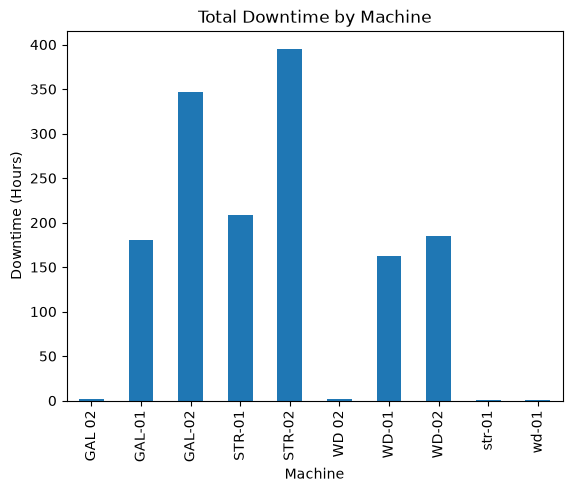

In [5]:
import matplotlib.pyplot as plt

# Total downtime for each machine
downtime = df.groupby("Machine")["Downtime_Hours"].sum()

downtime.plot(kind="bar")

plt.title("Total Downtime by Machine")
plt.xlabel("Machine")
plt.ylabel("Downtime (Hours)")
plt.show()

##----------------Chart 2 — Total Production by Machine----------##

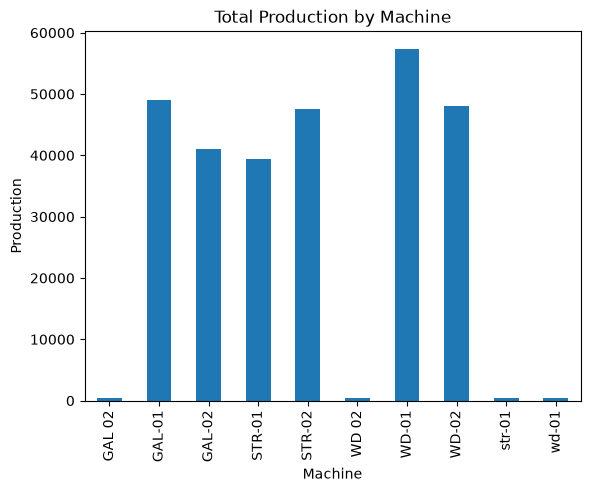

In [6]:
# Total production for each machine
production = df.groupby("Machine")["Actual_Production"].sum()

production.plot(kind="bar")

plt.title("Total Production by Machine")
plt.xlabel("Machine")
plt.ylabel("Production")
plt.show()

##-------- Chart 3 — Defect Rate by Machine---##

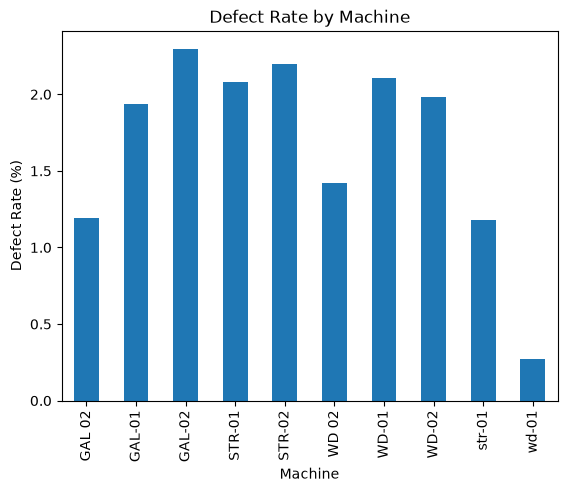

In [7]:
# Defect rate for each machine
defect_rate = (
    df.groupby("Machine")["Defect_Quantity"].sum()
    / df.groupby("Machine")["Actual_Production"].sum()
    * 100
)

defect_rate.plot(kind="bar")

plt.title("Defect Rate by Machine")
plt.xlabel("Machine")
plt.ylabel("Defect Rate (%)")
plt.show()

     ##-----------Chart 4 — Capacity Utilization by Machine----##

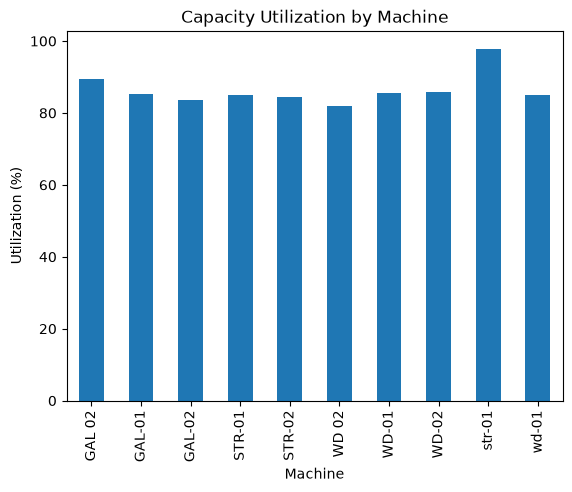

In [8]:
# Capacity utilization for each machine
utilization = (
    df.groupby("Machine")["Actual_Production"].sum()
    / df.groupby("Machine")["Production_Capacity"].sum()
    * 100
)

utilization.plot(kind="bar")

plt.title("Capacity Utilization by Machine")
plt.xlabel("Machine")
plt.ylabel("Utilization (%)")
plt.show()

###-----------Chart 5 — Downtime vs Production---###

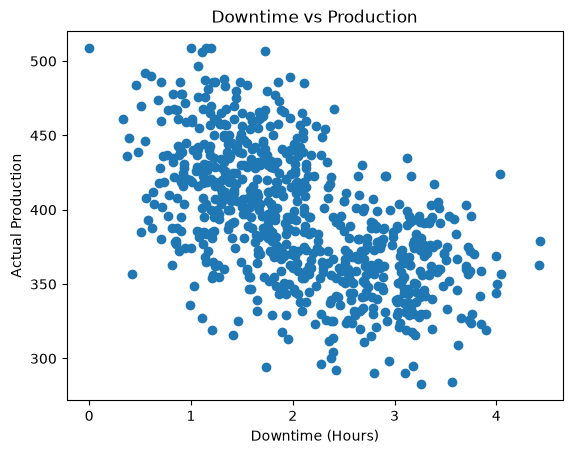

In [9]:
# Relationship between downtime and production
plt.scatter(df["Downtime_Hours"], df["Actual_Production"])

plt.title("Downtime vs Production")
plt.xlabel("Downtime (Hours)")
plt.ylabel("Actual Production")
plt.show()

In [ ]:
S